## HISPEC VFN Predicted Yield

Determine which young, nearby exoplanets from the Gaia DR4 mock catalog are detectable with HISPEC's Vector Fiber Nulling (VFN) mode using a phase-induced mask coronagraph at Keck.
p
**Workflow:**
1. Cross-match Gaia DR4 mock planets with MOCA young-star associations
2. Derive planet properties (Teff, log g, magnitudes) from Sonora substellar models
3. Run the specsim VFN exposure time calculator across J, H, K bands
4. Identify the optimal mask band per planet and visualize detectability

In [1]:
import numpy as np
import pandas as pd
from scipy.interpolate import LinearNDInterpolator

### Configuration
File paths, observability cuts, band parameters, and constants.

In [2]:
# File paths
moca_gaiadr3_file = '/Users/tatumumiamaka/Desktop/HISPEC/mocapy/query_result.csv'          
moca_members_file = '/Users/tatumumiamaka/Desktop/HISPEC/mocapy/summary_all_members.csv'   
moca_phot_file    = '/Users/tatumumiamaka/Desktop/HISPEC/mocapy/all_objects.csv'          
moca_ages_file    = '/Users/tatumumiamaka/Desktop/HISPEC/moca_association_ages.csv'
moca_parents_file = '/Users/tatumumiamaka/Desktop/HISPEC/moca_association_parents.csv'
dr4_catalog       = '/Users/tatumumiamaka/Desktop/HISPEC/DR4_mock_exoplanet_catalog.csv'
sonora_base       = '/Users/tatumumiamaka/Desktop/HISPEC/evolution_and_photometery/'
sonora_evo_path   = sonora_base + 'evolution_tables/evo_tables+0.0/nc+0.0_co1.0_mass'
sonora_mag_path   = sonora_base + 'photometry_tables/mag_table+0.0'

out_full       = '/Users/tatumumiamaka/Desktop/HISPEC/planets_populated.csv'
out_keck       = '/Users/tatumumiamaka/Desktop/HISPEC/planets_keck_observable.csv'
out_detect     = '/Users/tatumumiamaka/Desktop/HISPEC/planets_vfn_detectability.csv'

# Keck observability cuts
keck_dec_min       = -40.0
keck_dist_max_pc   = 200.0  
keck_memberships   = ('BF', 'HM', 'CM')

# Sonora photometry column indices (0-indexed) for 2MASS bands
# Header: Teff logg mass R/Rsun Y logKzz | MKO: Y Z J H K L' M' | 2MASS: J H Ks | ...
BAND_PARAMS = {
    'J': {'sonora_col': 13},  # 2MASS J
    'H': {'sonora_col': 14},  # 2MASS H
    'K': {'sonora_col': 15},  # 2MASS Ks
}

# lambda/D in arcsec for Keck (D=10m) at band center wavelengths
LOD_ARCSEC_BAND = {
    'J': 1.25e-6 / 10 * 206265,  # ~0.0258"
    'H': 1.65e-6 / 10 * 206265,  # ~0.0340"
    'K': 2.20e-6 / 10 * 206265,  # ~0.0454"
}

### Load MOCA association ages
Build an age lookup using MOCA's adopted ages, with fallbacks to parent associations and manual literature values.

In [3]:
# Association ages: keep only ADOPTED measurements
# data_association_ages holds several published ages per association; MOCA flags
# the preferred one with adopted=1. The reference cross-match script selects on
# adopted==1, so do the same here — otherwise a superseded age can win.
moca_ages_raw = pd.read_csv(moca_ages_file)
moca_ages = (
    moca_ages_raw[(moca_ages_raw['adopted'] == 1) & moca_ages_raw['age_myr'].notna()]
    .drop_duplicates(subset='moca_aid', keep='first')
    .set_index('moca_aid')
)
print(f'Associations with an adopted age: {len(moca_ages):,} / {moca_ages_raw["moca_aid"].nunique():,}')

# Parent association lookup, used as a fallback when a subgroup has no adopted age
moca_parents = dict(zip(*pd.read_csv(moca_parents_file)
                          .pipe(lambda d: (d['moca_aid'], d['parent_aid']))))

# Manual ages for real associations with no adopted age in the database 
# Values from Aniket's cross-match script (published Myr -> Gyr).
CRIUS_MANUAL_GYR = {
    'CRIUS224': {'age_gyr': 0.400, 'age_gyr_unc_neg': 0.300, 'age_gyr_unc_pos': 0.300},
    'CRIUS184': {'age_gyr': 0.950, 'age_gyr_unc_neg': 0.250, 'age_gyr_unc_pos': 0.250},
    'CRIUS116': {'age_gyr': 1.550, 'age_gyr_unc_neg': 1.450, 'age_gyr_unc_pos': 1.450},
    'CRIUS207': {'age_gyr': 0.300, 'age_gyr_unc_neg': np.nan, 'age_gyr_unc_pos': np.nan},
    'CRIUS222': {'age_gyr': 0.400, 'age_gyr_unc_neg': 0.300, 'age_gyr_unc_pos': 0.300},
}


def adopted_age_gyr(moca_aid):
    """Adopted age [Gyr] for one association: direct -> parent -> manual -> NaN."""
    if moca_aid in moca_ages.index:
        return float(moca_ages.loc[moca_aid, 'age_gyr'])
    parent = moca_parents.get(moca_aid)
    if parent is not None and parent in moca_ages.index:
        return float(moca_ages.loc[parent, 'age_gyr'])
    if moca_aid in CRIUS_MANUAL_GYR:
        return CRIUS_MANUAL_GYR[moca_aid]['age_gyr']
    return np.nan


Associations with an adopted age: 9,091 / 10,227


### Cross-match Gaia DR4 mock catalog with MOCA
Match DR4 mock exoplanet host stars to MOCA young-star associations via Gaia DR3 source IDs. Keep bona fide (BF), high-likelihood (HM), and candidate (CM) members observable from Keck. Assign adopted ages and derive host Teff from MOCA spectral types.

In [4]:
# Step 1: cat_gaiadr3 — the base dataset (moca_oid <-> Gaia DR3 source_id)
gaia_dr3 = pd.read_csv(moca_gaiadr3_file, usecols=['moca_oid', 'source_id'])
gaia_dr3['source_id'] = pd.to_numeric(gaia_dr3['source_id'], errors='coerce').astype('Int64')
print(f'cat_gaiadr3 objects:            {len(gaia_dr3):,}')

# Step 2: DR4 mock exoplanet catalog 
dr4_all = pd.read_csv(dr4_catalog, encoding='utf-8')
dr4_all['source_id'] = pd.to_numeric(dr4_all['Gaia source ID'], errors='coerce').astype('Int64')
print(f'DR4 mock planets:               {len(dr4_all):,}')

# Step 3: cross-match  (== reference's moca_crossmatch_DR4_mock.csv) 
# Objects present in BOTH cat_gaiadr3 and the DR4 mock catalog.
dr4_ids = set(dr4_all['source_id'].dropna())
moca_crossmatch = (
    gaia_dr3[gaia_dr3['source_id'].isin(dr4_ids)]
    .drop_duplicates(subset=['moca_oid', 'source_id'])
    .copy()
)
print(f'MOCA x DR4 cross-matched stars: {len(moca_crossmatch):,}')

# Step 4: attach membership info 
# == SELECT * FROM summary_all_members JOIN tmp_table USING(moca_oid)
# One row per membership claim, so stars in overlapping associations repeat here.
members = pd.read_csv(moca_members_file)
df_membership = members.merge(moca_crossmatch, on='moca_oid', how='inner')
print(f'Membership rows (pre-cut):      {len(df_membership):,} '
      f'({df_membership["moca_oid"].nunique():,} unique stars)')

# Step 5: keep BF/HM/CM members observable from Keck 
index_members = (
    df_membership['moca_mtid'].isin(keck_memberships)
    & (df_membership['dec'] > keck_dec_min)
)
df_obs = df_membership[index_members].copy()
print(f'After {keck_memberships} + dec > {keck_dec_min}: {len(df_obs):,} rows '
      f'({df_obs["moca_oid"].nunique():,} unique stars)')

# Step 6: adopted age per association (direct -> parent -> manual)
age_by_aid = {aid: adopted_age_gyr(aid) for aid in df_obs['moca_aid'].dropna().unique()}
df_obs['host_age_gyr'] = df_obs['moca_aid'].map(age_by_aid)
n_aged = df_obs['host_age_gyr'].notna().sum()
print(f'Membership rows with an age:    {n_aged:,} / {len(df_obs):,}')

# Step 7: collapse to one row per star 
# A star claimed in >1 association gets the median of its association ages,
ages_per_star = (
    df_obs.groupby('moca_oid', as_index=False)
          .agg(host_age_gyr=('host_age_gyr', 'median'),
               moca_aid=('moca_aid', 'first'),
               moca_mtid=('moca_mtid', 'first'),
               dec=('dec', 'first'),
               sptn=('sptn', 'first'))
)

# Step 8: rejoin source_id, attach 2MASS photometry 
moca_df = moca_crossmatch.merge(ages_per_star, on='moca_oid', how='inner')

phot = pd.read_csv(moca_phot_file, usecols=['moca_oid', 'j_m', 'h_m', 'k_m'])
phot = phot.drop_duplicates(subset='moca_oid', keep='first')
moca_df = moca_df.merge(phot, on='moca_oid', how='left')

# Gaia IDs are large ints — carry as plain strings so they match the DR4 column exactly
moca_df['gaia_id'] = moca_df['source_id'].astype('Int64').astype(str)

# Step 9: host effective temperature from spectral type 
# Each host gets its own Teff rather than one assumed value for the whole sample.
# Anchors below are main-sequence dwarf Teffs from Pecaut & Mamajek (2013),
# the same compilation MOCA carries as data_mamajek_table.
SPTN_ANCHORS = np.array([-50, -45, -42, -40, -35, -30, -25, -20, -18, -15, -12,
                         -10,  -8,  -5,  -3,   0,   1,   2,   3,   4,   5,
                           6,   7,   8,   9,  10,  12,  15,  20])
TEFF_ANCHORS = np.array([31400, 15700, 12300, 9700, 8080, 7220, 6510, 5920, 5770, 5660, 5490,
                          5280, 5040, 4410, 4050, 3870, 3700, 3550, 3410, 3200, 3060,
                          2810, 2680, 2570, 2380, 2270, 2100, 1650, 1300], dtype=float)


def sptn_to_teff(sptn):
    """Main-sequence effective temperature [K] for a MOCA numeric spectral type."""
    sptn = np.asarray(sptn, dtype=float)
    teff = np.interp(sptn, SPTN_ANCHORS, TEFF_ANCHORS)   # clamps at the anchor ends
    return np.where(np.isfinite(sptn), teff, np.nan)


moca_df['host_teff_k'] = sptn_to_teff(moca_df['sptn'].values)

# Stars with no spectral type fall back to the sample median rather than a solar
# default — for a K/M-dominated sample the median is far more representative.
n_no_spt = moca_df['host_teff_k'].isna().sum()
if n_no_spt:
    teff_fallback = float(np.nanmedian(moca_df['host_teff_k']))
    moca_df['host_teff_k'] = moca_df['host_teff_k'].fillna(teff_fallback)
    print(f'Hosts with no spectral type: {n_no_spt:,} -> using sample median {teff_fallback:.0f} K')

print(f'\nHost Teff: median {moca_df["host_teff_k"].median():.0f} K, '
      f'range {moca_df["host_teff_k"].min():.0f}-{moca_df["host_teff_k"].max():.0f} K')

print(f'\nTarget stars (unique moca_oid): {len(moca_df):,}')
print(f'  with an age:                  {moca_df["host_age_gyr"].notna().sum():,}')
print(f'  with H-band photometry:       {moca_df["h_m"].notna().sum():,}')
print(f'Membership mix: {moca_df["moca_mtid"].value_counts().to_dict()}')


cat_gaiadr3 objects:            4,413,101
DR4 mock planets:               7,545
MOCA x DR4 cross-matched stars: 3,227
Membership rows (pre-cut):      1,847 (628 unique stars)
After ('BF', 'HM', 'CM') + dec > -40.0: 569 rows (241 unique stars)
Membership rows with an age:    533 / 569
Hosts with no spectral type: 6 -> using sample median 4725 K

Host Teff: median 4725 K, range 2615-8080 K

Target stars (unique moca_oid): 241
  with an age:                  208
  with H-band photometry:       159
Membership mix: {'CM': 151, 'HM': 84, 'BF': 6}


### Merge DR4 planets with MOCA host stars
Join the mock exoplanet catalog with the young-star target list. Drop planets whose host has no adopted age.

In [5]:
# Merge the young-star target list with the DR4 mock planets
dr4_all['gaia_id'] = dr4_all['source_id'].astype('Int64').astype(str)

merged_df = dr4_all.merge(
    moca_df[['gaia_id', 'moca_oid', 'moca_mtid', 'moca_aid', 'dec',
             'j_m', 'h_m', 'k_m', 'host_age_gyr', 'host_teff_k']],
    on='gaia_id',
    how='inner',
)

print(f'DR4 planets:                 {len(dr4_all):,}')
print(f'Planets around target stars: {len(merged_df):,} '
      f'({merged_df["moca_oid"].nunique():,} unique stars)')

# Drop planets whose host has no age 
n_before = len(merged_df)
merged_df_with_age = merged_df[merged_df['host_age_gyr'].notna()].copy()
print(f'\nRows with age:  {len(merged_df_with_age):,} / {n_before:,}')
print(f'Rows dropped:   {n_before - len(merged_df_with_age):,}  (no adopted age in MOCA)')
print(f'Unique stars:   {merged_df_with_age["moca_oid"].nunique():,}')
print(merged_df_with_age[['gaia_id', 'moca_aid', 'moca_mtid', 'host_age_gyr']].head())


DR4 planets:                 7,545
Planets around target stars: 241 (241 unique stars)

Rows with age:  208 / 241
Rows dropped:   33  (no adopted age in MOCA)
Unique stars:   208
               gaia_id  moca_aid moca_mtid  host_age_gyr
0  1329517301255977728       GRX        CM      0.224500
2  1579822532067683328  CRIUS147        HM      0.300000
4  1416761796573117696     CCBER        HM      0.562000
5   276302672155059328  CRIUS203        HM      0.669989
6  2719774403671398016      CUMA        CM      0.414000


### Orbital mechanics
Compute semi-major axes via Kepler's 3rd law and maximum projected sky separations by sampling the full Keplerian orbit.

In [6]:
# Semi-major axis via Kepler's 3rd law 
Mjup_to_Msun = 9.546e-4
P_yr = merged_df_with_age['Best-fit period [days]'] / 365.25
Mtot = merged_df_with_age['Stellar mass [M_\\odot]'] + \
       merged_df_with_age['True planet mass [M_J]'] * Mjup_to_Msun
merged_df_with_age['planet_a_au'] = (Mtot * P_yr**2) ** (1/3)

# Maximum projected separation across full orbit 
def solve_kepler(M, e, tol=1e-10):
    """Solve Kepler's equation M = E - e sin(E) for eccentric anomaly E."""
    M = np.asarray(M, dtype=float)
    E = M.copy()
    for _ in range(50):
        dE = (E - e * np.sin(E) - M) / (1.0 - e * np.cos(E))
        E -= dE
        if np.all(np.abs(dE) < tol):
            break
    return E

def max_projected_separation(a_au, e, omega, inc, n_samples=1000):
    """Maximum projected sky separation over a full Keplerian orbit.

    Samples n_samples orbital phases and returns the largest projected
    sky separation, representing the best observing opportunity.

    Parameters
    ----------
    a_au  : ndarray  Semi-major axis [AU]
    e     : ndarray  Eccentricity
    omega : ndarray  Argument of periastron [rad]
    inc   : ndarray  Inclination [rad]

    Returns
    -------
    ndarray  Maximum projected separation [AU] per planet
    """
    M_samples = np.linspace(0, 2.0 * np.pi, n_samples, endpoint=False)
    n_p       = len(a_au)

    M_grid     = np.broadcast_to(M_samples, (n_p, n_samples))
    e_g        = e[:, None]
    a_g        = a_au[:, None]
    omega_g    = omega[:, None]
    inc_g      = inc[:, None]

    E_g  = solve_kepler(M_grid, e_g)
    nu_g = 2.0 * np.arctan2(
        np.sqrt(1.0 + e_g) * np.sin(E_g / 2.0),
        np.sqrt(1.0 - e_g) * np.cos(E_g / 2.0),
    )
    r_g   = a_g * (1.0 - e_g * np.cos(E_g))
    sep_g = r_g * np.sqrt(1.0 - np.sin(omega_g + nu_g)**2 * np.sin(inc_g)**2)

    return np.max(sep_g, axis=1)


e_arr     = merged_df_with_age['Best-fit eccentricity'].values
omega_arr = np.radians(merged_df_with_age['Best-fit omega [deg]'].values)
inc_arr   = np.radians(merged_df_with_age['Best-fit inclination [deg]'].values)
a_au_arr  = merged_df_with_age['planet_a_au'].values

sep_max_au  = max_projected_separation(a_au_arr, e_arr, omega_arr, inc_arr)
distance_pc = merged_df_with_age['True distance [pc]'].values
sep_max_mas = (sep_max_au / distance_pc) * 1000.0

merged_df_with_age['planet_sep_max_au']  = sep_max_au
merged_df_with_age['planet_sep_max_mas'] = sep_max_mas
merged_df_with_age['planet_apoapsis_au'] = a_au_arr * (1.0 + e_arr)

print(f'Full population: {len(merged_df_with_age):,} planets')
print(f'  Semi-major axis:   median = {merged_df_with_age["planet_a_au"].median():.2f} AU')
print(f'  Apoapsis:          median = {merged_df_with_age["planet_apoapsis_au"].median():.2f} AU')
print(f'  Max projected sep: median = {np.median(sep_max_mas):.2f} mas, '
      f'range = [{np.min(sep_max_mas):.3f}, {np.max(sep_max_mas):.1f}] mas')

Full population: 208 planets
  Semi-major axis:   median = 1.76 AU
  Apoapsis:          median = 2.32 AU
  Max projected sep: median = 18.41 mas, range = [5.912, 260.0] mas


### Apply Keck observability cuts
Filter to planets within 200 pc (membership and declination cuts were applied upstream).

In [7]:
def filter_keck_observable(planets_df):
    """Apply Keck observability cuts: membership, declination, and distance.

    Membership + declination cuts were applied upstream in Section 3 (Step 5).
    The distance cut (<=200 pc) is applied here explicitly.
    """
    n_before = len(planets_df)
    mask = planets_df['True distance [pc]'] <= keck_dist_max_pc
    out = planets_df[mask].copy()

    print(f'Keck observability cuts:')
    print(f'  membership types: {keck_memberships} (applied upstream)')
    print(f'  dec > {keck_dec_min} deg (applied upstream)')
    print(f'  distance <= {keck_dist_max_pc} pc: {mask.sum():,} / {n_before:,} kept')
    print(f'  planets: {len(out):,}  ({out["moca_oid"].nunique():,} unique stars)')
    return out

In [32]:
observable_df = filter_keck_observable(merged_df_with_age)
observable_df.to_csv(out_keck, index=False)
print(f'Saved → {out_keck}')
print(np.mean(observable_df['True distance [pc]']))

Keck observability cuts:
  membership types: ('BF', 'HM', 'CM') (applied upstream)
  dec > -40.0 deg (applied upstream)
  distance <= 200.0 pc: 187 / 208 kept
  planets: 187  (187 unique stars)
Saved → /Users/tatumumiamaka/Desktop/HISPEC/planets_keck_observable.csv
99.79103689839573


### Population plots
Mass vs. separation for the full and Keck-observable planet samples.

/var/folders/ys/zj4jsjr11s98rffk8szmf81c0000gn/T/ipykernel_95094/3344924645.py:15: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(


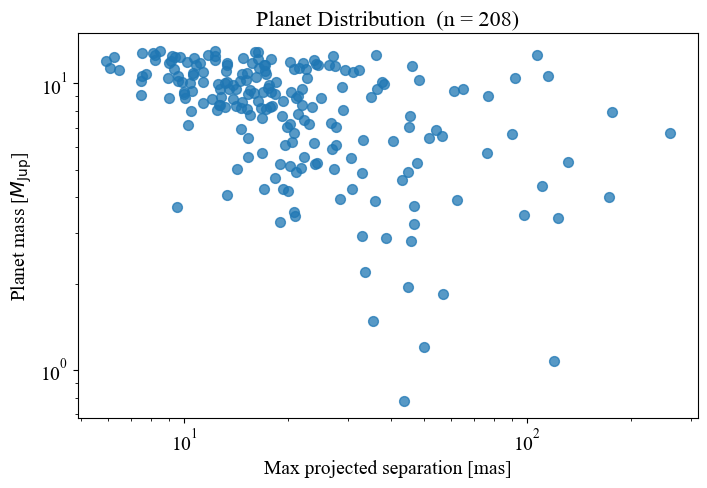

In [78]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif', 'Liberation Serif']

plt.rcParams['font.size'] = 14         # Base text size
plt.rcParams['axes.labelsize'] = 14   # Axis labels (X and Y)
plt.rcParams['axes.titlesize'] = 16    # Plot title
plt.rcParams['xtick.labelsize'] = 14    # X-axis tick labels
plt.rcParams['ytick.labelsize'] = 14    # Y-axis tick labels
plt.rcParams['legend.fontsize'] = 14    # Legend font size

fig, ax = plt.subplots(figsize=(8, 5))

sc = ax.scatter(
    merged_df_with_age['planet_sep_max_mas'],
    merged_df_with_age['Best-fit planet mass [M_J]'],
    cmap='RdYlGn_r',
    s=50, alpha=0.75
)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Max projected separation [mas]')
ax.set_ylabel('Planet mass [$M_\\mathrm{Jup}$]')
ax.set_title(f'Planet Distribution  (n = {len(merged_df_with_age):,})')

plt.savefig('/Users/tatumumiamaka/Desktop/HISPEC/planet_population.png', dpi=500)
plt.show()

/var/folders/ys/zj4jsjr11s98rffk8szmf81c0000gn/T/ipykernel_95094/1062930630.py:15: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(


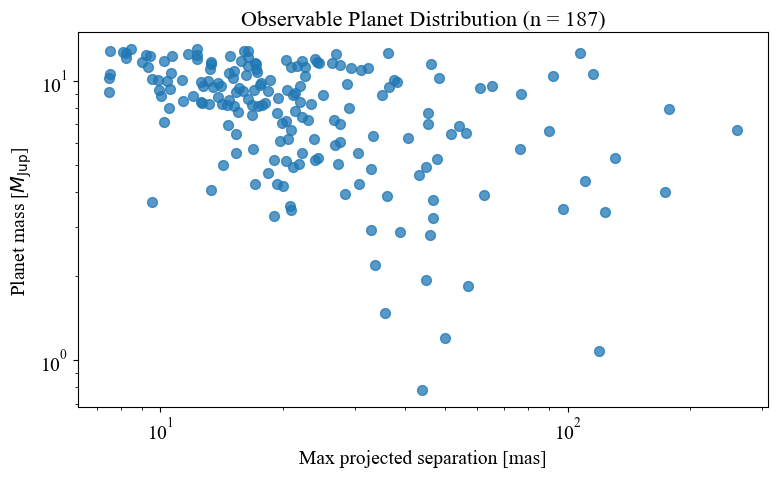

In [79]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif', 'Liberation Serif']

plt.rcParams['font.size'] = 14         # Base text size
plt.rcParams['axes.labelsize'] = 14   # Axis labels (X and Y)
plt.rcParams['axes.titlesize'] = 16    # Plot title
plt.rcParams['xtick.labelsize'] = 14    # X-axis tick labels
plt.rcParams['ytick.labelsize'] = 14    # Y-axis tick labels
plt.rcParams['legend.fontsize'] = 14    # Legend font size

fig, ax = plt.subplots(figsize=(8, 5))

sc = ax.scatter(
    observable_df['planet_sep_max_mas'],
    observable_df['Best-fit planet mass [M_J]'],
    cmap='RdYlGn_r',
    s=50, alpha=0.75
)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Max projected separation [mas]')
ax.set_ylabel('Planet mass [$M_\\mathrm{Jup}$]')
ax.set_title(f'Observable Planet Distribution (n = {len(observable_df):,})')

plt.savefig('/Users/tatumumiamaka/Desktop/HISPEC/keck_observable_planets.png', dpi=500)
plt.tight_layout()
plt.show()

### Derive planet properties from Sonora models
Use Sonora Bobcat evolution tables to map (mass, age) to (Teff, log g), and photometry tables to get absolute J/H/K magnitudes. Convert to apparent magnitudes using each planet's distance.

In [15]:
def load_sonora_photometry(path, band_params):
    """Load Sonora Bobcat photometry table and build magnitude interpolators.

    Reads the fixed-format Sonora photometry file (11-line header) and creates
    a LinearNDInterpolator for each photometric band, mapping (T_eff, log g) to
    absolute magnitude at 10 pc. Entries flagged -99.000 are excluded.

    Parameters
    ----------
    path : str
        Path to the Sonora photometry file (e.g. 'mag_table+0.0').
    band_params : dict
        Dictionary keyed by band name (e.g. 'J', 'H', 'K'), where each value
        is a dict containing at least 'sonora_col' (int) — the 0-indexed column
        position of that band's magnitude in the file.

    Returns
    -------
    dict of LinearNDInterpolator
        Keys are band names, values are interpolators: f(T_eff, log_g) → mag.
    """

    band_columns = {
        band_name: params['sonora_col']
        for band_name, params in band_params.items()
    }

    band_data = {band_name: [] for band_name in band_columns}

    with open(path) as file:
        for line_num, line in enumerate(file):
            if line_num < 11:
                continue

            columns = line.split()
            max_column_needed = max(band_columns.values())

            if len(columns) < max_column_needed + 1:
                continue

            try:
                teff = float(columns[0])
                logg = float(columns[1])
            except ValueError:
                continue

            if teff <= 0:
                continue

            for band_name, column_index in band_columns.items():
                try:
                    magnitude = float(columns[column_index])
                except (ValueError, IndexError):
                    continue

                if magnitude != -99.0:
                    band_data[band_name].append((teff, logg, magnitude))

    interpolators = {}

    for band_name, data_points in band_data.items():
        if not data_points:
            continue

        data_array = np.array(data_points)

        interpolators[band_name] = LinearNDInterpolator(
            data_array[:, :2],
            data_array[:, 2]
        )

    point_counts = {band: len(band_data[band]) for band in interpolators}
    print(f'{point_counts} grid points per band')

    return interpolators


# Load Sonora Photometry Models 
print(f'Loading Sonora photometry: {sonora_mag_path}')
sonora_interps = load_sonora_photometry(sonora_mag_path, BAND_PARAMS)

# Load Sonora Evolution Models 
print(f'\nLoading Sonora evolution: {sonora_evo_path}')
evo_data = []
with open(sonora_evo_path) as f:
    for i, line in enumerate(f):
        if i < 2:
            continue
        cols = line.split()
        if len(cols) < 5:
            continue
        try:
            mass, age, logL, teff, logg = float(cols[0]), float(cols[1]), float(cols[2]), float(cols[3]), float(cols[4])
            evo_data.append((mass, age, teff, logg))
        except ValueError:
            continue

evo_arr = np.array(evo_data)
interp_teff = LinearNDInterpolator(evo_arr[:, :2], evo_arr[:, 2])
interp_logg = LinearNDInterpolator(evo_arr[:, :2], evo_arr[:, 3])
print(f'  {len(evo_arr)} grid points loaded')

# Prepare Observable Targets 
df = observable_df.copy()
df.rename(columns={'j_m': 'host_j_mag', 'h_m': 'host_h_mag', 'k_m': 'host_k_mag'}, inplace=True)
print(f'\n{len(df):,} targets')

# Derive planet T_eff and log g from Sonora evolution models
Mjup_to_Msun = 9.546e-4
planet_mass_msun = df['Best-fit planet mass [M_J]'].values * Mjup_to_Msun
evo_pts = np.column_stack([planet_mass_msun, df['host_age_gyr'].values])
df['planet_teff_k'] = interp_teff(evo_pts)
df['planet_logg'] = interp_logg(evo_pts)

n_valid_teff = np.isfinite(df['planet_teff_k']).sum()
print(f'  Planets with valid T_eff/log g: {n_valid_teff:,} / {len(df):,}')

# Planet Magnitudes from Sonora photometry models
pts = np.column_stack([df['planet_teff_k'].values, df['planet_logg'].values])
dist_mod = 5.0 * np.log10(df['True distance [pc]'].values / 10.0)

print('\nInterpolating Sonora magnitudes...')
for band in BAND_PARAMS:
    abs_col = f'planet_{band.lower()}_abs'
    app_col = f'planet_{band.lower()}_app'
    if band in sonora_interps:
        mag_abs = sonora_interps[band](pts)
    else:
        mag_abs = np.full(len(df), np.nan)
    df[abs_col] = mag_abs
    df[app_col] = mag_abs + dist_mod
    n_valid = np.isfinite(df[app_col]).sum()
    print(f'  {band}: {n_valid:,} / {len(df):,} valid')

# Maximum Angular Separations 
theta_arcsec = df['planet_sep_max_au'].values / df['True distance [pc]'].values 
df['planet_sep_arcsec'] = theta_arcsec
df['planet_sep_mas']    = theta_arcsec * 1000.0

print('\nMaximum projected separations in λ/D:')
for band in BAND_PARAMS:
    df[f'planet_sep_lod_{band}'] = theta_arcsec / LOD_ARCSEC_BAND[band]
    print(f'  {band}: median = {df[f"planet_sep_lod_{band}"].median():.2f} λ/D')


Loading Sonora photometry: /Users/tatumumiamaka/Desktop/HISPEC/evolution_and_photometery/photometry_tables/mag_table+0.0
{'J': 429, 'H': 429, 'K': 429} grid points per band

Loading Sonora evolution: /Users/tatumumiamaka/Desktop/HISPEC/evolution_and_photometery/evolution_tables/evo_tables+0.0/nc+0.0_co1.0_mass
  1422 grid points loaded

187 targets
  Planets with valid T_eff/log g: 187 / 187

Interpolating Sonora magnitudes...
  J: 186 / 187 valid
  H: 186 / 187 valid
  K: 186 / 187 valid

Maximum projected separations in λ/D:
  J: median = 0.79 λ/D
  H: median = 0.60 λ/D
  K: median = 0.45 λ/D


### Snap Teff to spectral model grids
Specsim loads spectral files by exact Teff. Snap planet Teff to the Sonora grid (200--2300 K) and host Teff to the Phoenix grid (2300--12000 K, 100 K steps).

In [16]:
# Snap planet Teff to nearest Sonora spectral grid point for specsim file lookup.
# specsim constructs filenames as sp_t{int(teff)}g316nc_m0.0, so the Teff must
# exactly match an available file. This column is ONLY used for specsim's spectral
# file selection — the physical planet_teff_k is preserved unchanged.

SONORA_TEFFS = np.array([200, 225, 250, 275, 300, 325, 350, 375, 400, 425, 450,
                         475, 500, 525, 550, 575, 600, 650, 700, 750, 800, 850,
                         900, 950, 1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700,
                         1800, 1900, 2000, 2100, 2200, 2300])

# For hosts (Teff >= 2300K), specsim uses Phoenix models at 100K steps.
# Available Phoenix files should cover the host Teff range.
PHOENIX_TEFFS = np.arange(2300, 12100, 100)

def snap_to_grid(teff_arr, grid):
    """Snap each value to the nearest grid point."""
    teff_arr = np.asarray(teff_arr, dtype=float)
    idx = np.array([np.abs(grid - t).argmin() if np.isfinite(t) else 0 for t in teff_arr])
    result = grid[idx].astype(float)
    result[~np.isfinite(teff_arr)] = np.nan
    return result

# Planet Teff -> Sonora grid (all planets should be < 2300K)
df['planet_teff_specsim'] = snap_to_grid(df['planet_teff_k'].values, SONORA_TEFFS)

# Host Teff -> Phoenix grid (all hosts should be >= 2300K)
df['host_teff_specsim'] = snap_to_grid(df['host_teff_k'].values, PHOENIX_TEFFS)

print('Planet Teff snapping (Sonora grid):')
print(f'  original range: {df["planet_teff_k"].min():.0f} - {df["planet_teff_k"].max():.0f} K')
print(f'  snapped range:  {df["planet_teff_specsim"].min():.0f} - {df["planet_teff_specsim"].max():.0f} K')
print(f'  unique grid points used: {sorted(df["planet_teff_specsim"].dropna().unique().astype(int))}')
print(f'\nHost Teff snapping (Phoenix grid):')
print(f'  original range: {df["host_teff_k"].min():.0f} - {df["host_teff_k"].max():.0f} K')
print(f'  snapped range:  {df["host_teff_specsim"].min():.0f} - {df["host_teff_specsim"].max():.0f} K')
print(f'  unique grid points used: {sorted(df["host_teff_specsim"].dropna().unique().astype(int))}')

# Summary of columns ready for specsim
print(f'\n--- Columns ready for specsim VFN ETC ---')
print(f'  so.stel.teff    <- host_teff_specsim  (snapped to Phoenix grid)')
print(f'  so.stel.mag     <- host_h_mag         (2MASS H)')
print(f'  so.stel.pl_teff <- planet_teff_specsim (snapped to Sonora grid)')
print(f'  so.stel.pl_mag  <- planet_h_app       (apparent 2MASS H from Sonora)')
print(f'  so.stel.pl_sep  <- planet_sep_mas     (max projected separation)')

Planet Teff snapping (Sonora grid):
  original range: 195 - 1996 K
  snapped range:  200 - 2000 K
  unique grid points used: [200, 225, 250, 300, 325, 350, 375, 400, 425, 450, 475, 500, 525, 550, 575, 600, 650, 700, 750, 800, 850, 900, 950, 1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 2000]

Host Teff snapping (Phoenix grid):
  original range: 2615 - 7392 K
  snapped range:  2600 - 7400 K
  unique grid points used: [2600, 2900, 3100, 3200, 3300, 3400, 3500, 3700, 3800, 3900, 4000, 4100, 4200, 4300, 4400, 4500, 4600, 4700, 4800, 4900, 5000, 5100, 5200, 5300, 5500, 5600, 5700, 5800, 5900, 6100, 6200, 6400, 6500, 6700, 6800, 6900, 7200, 7400]

--- Columns ready for specsim VFN ETC ---
  so.stel.teff    <- host_teff_specsim  (snapped to Phoenix grid)
  so.stel.mag     <- host_h_mag         (2MASS H)
  so.stel.pl_teff <- planet_teff_specsim (snapped to Sonora grid)
  so.stel.pl_mag  <- planet_h_app       (apparent 2MASS H from Sonora)
  so.stel.pl_sep  <- planet_sep_mas     (max pr

### VFN exposure time calculator
Run the specsim VFN ETC for each planet across J, H, K bands **and** both mask types (charge-1 vortex, charge-2 vortex). Each combination uses its own band-specific coupling profile. The configuration (mask + band) yielding the shortest CCF SNR=5 exposure time is selected as optimal.

In [22]:
import sys, os

REPO_ROOT = '/Users/tatumumiamaka/Documents/GitHub/specsim'
sys.path.insert(0, REPO_ROOT)
os.chdir(REPO_ROOT)

from specsim.objects import load_object, PATH_ATTR_SUFFIXES
from specsim.load_inputs import fill_data

# TODO: Check this?
# Available coupling files have ttDynamic = 3, 6, 9 mas
AVAILABLE_TT_DYN = np.array([3.0, 6.0, 9.0])

def clamp_tt_dynamic(so):
    """Snap ao.tt_dynamic to the nearest available coupling file value."""
    so.ao.tt_dynamic = float(AVAILABLE_TT_DYN[np.argmin(np.abs(AVAILABLE_TT_DYN - so.ao.tt_dynamic))])

# Band-specific column mapping
BAND_MAG_COLS = {
    'J': {'host_mag': 'host_j_mag', 'planet_mag': 'planet_j_app'},
    'H': {'host_mag': 'host_h_mag', 'planet_mag': 'planet_h_app'},
    'K': {'host_mag': 'host_k_mag', 'planet_mag': 'planet_k_app'},
}

# --- Mask configurations: (mask_name, vortex_charge, {band: coupling_file}) ---
VFN_BASE = './data/instrument/hispec/throughput/vfn/'

MASK_CONFIGS = {
    'charge1': {
        'charge': 1,
        'label': 'Charge-1 Vortex',
        'bands': {
            'J': VFN_BASE + 'coupling_vs_separation_charge1-vortex_J-band.csv',
            'H': VFN_BASE + 'coupling_vs_separation_charge1-vortex_H-band.csv',
            'K': VFN_BASE + 'coupling_vs_separation_charge1-vortex_K-band.csv',
        }
    },
    'charge2': {
        'charge': 2,
        'label': 'Charge-2 Vortex',
        'bands': {
            'J': VFN_BASE + 'coupling_vs_separation_charge2-vortex_J-band.csv',
            'H': VFN_BASE + 'coupling_vs_separation_charge2-vortex_H-band.csv',
            'K': VFN_BASE + 'coupling_vs_separation_charge2-vortex_K-band.csv',
        }
    },
    'phaseknife': {
        'charge': 1,  # phase knife contrast model uses charge=1 approx (charge=0 model is incomplete)
        'label': 'Phase Knife',
        'bands': {
            'J': VFN_BASE + 'coupling_vs_separation_phase_knife_J-band.csv',
            'H': VFN_BASE + 'coupling_vs_separation_phase-knife_H-band.csv',
            'K': VFN_BASE + 'coupling_vs_separation_phase_knife_K-band.csv',
        }
    },
}

# Verify coupling files exist
for mask, cfg in MASK_CONFIGS.items():
    for band, path in list(cfg['bands'].items()):
        if not os.path.isfile(path):
            print(f'WARNING: missing {path} — skipping {mask}/{band}')
            del cfg['bands'][band]
        else:
            print(f'  OK: {mask}/{band} -> {os.path.basename(path)}')

# Filter to planets with all required data (need all 3 bands)
required_cols = ['host_teff_specsim', 'planet_teff_specsim', 'planet_sep_mas', 'planet_logg',
                 'host_j_mag', 'host_h_mag', 'host_k_mag',
                 'planet_j_app', 'planet_h_app', 'planet_k_app']
etc_df = df.dropna(subset=required_cols).copy()
print(f'\nPlanets with complete data for ETC: {len(etc_df)} / {len(df)}')

# Load config
so = load_object('configs/hispec_vfn_etc.cfg')

# Fix double './' prefix on path attributes
for section in (so.filt, so.stel, so.tel, so.inst, so.ao, so.obs, so.track):
    for attr, value in vars(section).items():
        if attr.endswith(PATH_ATTR_SUFFIXES) and isinstance(value, str) and value.startswith('././'):
            setattr(section, attr, value[2:])

# Set first target to initialize
row0 = etc_df.iloc[0]
so.stel.teff     = row0['host_teff_specsim']
so.stel.mag      = row0['host_h_mag']
so.stel.pl_teff  = row0['planet_teff_specsim']
so.stel.pl_mag   = row0['planet_h_app']
so.stel.pl_sep   = row0['planet_sep_mas']
so.stel.pl_logg  = row0['planet_logg']

# Initialize pipeline
fd = fill_data.__new__(fill_data)
fd.x = np.arange(so.inst.l0, so.inst.l1, 0.0005)
fd.bands = {'y': [980,1100], 'J': [1170,1327], 'H': [1490,1780], 'K': [1990,2460]}
so.inst.y, so.inst.J, so.inst.H, so.inst.K = fd.bands['y'].copy(), fd.bands['J'].copy(), fd.bands['H'].copy(), fd.bands['K'].copy()

fd.filter(so)
fd.stellar(so)
fd.telluric(so)
fd.ao(so)
clamp_tt_dynamic(so)
fd.instrument(so)
fd.observe(so)
fd.compute_etc(so, so.obs.target_snr)
fd.compute_ccf_snr_etc(so, so.obs.target_ccf_snr)
print('Pipeline initialized successfully.')

# --- Loop over all planets × all masks × all bands ---
all_results = []

for i, (idx, row) in enumerate(etc_df.iterrows()):
    result = {
        'df_index':        idx,
        'gaia_id':         row['gaia_id'],
        'host_teff':       row['host_teff_k'],
        'planet_teff':     row['planet_teff_k'],
        'planet_logg':     row['planet_logg'],
        'planet_sep_mas':  row['planet_sep_mas'],
        'planet_mass_mj':  row['Best-fit planet mass [M_J]'],
        'planet_sep_max_au': row['planet_sep_max_au'],
        'distance_pc':     row['True distance [pc]'],
    }

    for mask_name, mask_cfg in MASK_CONFIGS.items():
        so.inst.vfn_charge = mask_cfg['charge']

        for band in ['J', 'H', 'K']:
            col_key = f'etc_{mask_name}_{band}_s'

            if band not in mask_cfg['bands']:
                result[col_key] = np.nan
                continue

            cols = BAND_MAG_COLS[band]
            so.stel.teff     = row['host_teff_specsim']
            so.stel.mag      = row[cols['host_mag']]
            so.stel.pl_teff  = row['planet_teff_specsim']
            so.stel.pl_mag   = row[cols['planet_mag']]
            so.stel.pl_sep   = row['planet_sep_mas']
            so.stel.pl_logg  = row['planet_logg']
            so.filt.band     = band
            so.inst.vfn_coupling_file = mask_cfg['bands'][band]

            try:
                fd.filter(so)
                fd.stellar(so)
                fd.ao(so)
                clamp_tt_dynamic(so)
                fd.instrument(so)
                fd.observe(so)
                fd.compute_etc(so, so.obs.target_snr)
                fd.compute_ccf_snr_etc(so, so.obs.target_ccf_snr)

                etc_val = getattr(so.obs, f'etc_ccf_snr_{band}', np.nan)
                result[col_key] = etc_val
            except Exception as e:
                if i < 3:
                    print(f'  [{i+1}] {mask_name}/{band} FAILED gaia_id={row["gaia_id"]}: {e}')
                result[col_key] = np.nan

    all_results.append(result)

    if (i+1) % 25 == 0 or (i+1) == len(etc_df):
        print(f'  Processed {i+1}/{len(etc_df)} planets')

results_df = pd.DataFrame(all_results)

# Convert to hours
for mask_name in MASK_CONFIGS:
    for band in ['J', 'H', 'K']:
        s_col = f'etc_{mask_name}_{band}_s'
        hr_col = f'etc_{mask_name}_{band}_hr'
        if s_col in results_df.columns:
            results_df[hr_col] = results_df[s_col] / 3600.0

# Per-mask best band
for mask_name in MASK_CONFIGS:
    mask_hr_cols = [f'etc_{mask_name}_{b}_hr' for b in ['J', 'H', 'K']
                    if f'etc_{mask_name}_{b}_hr' in results_df.columns]
    results_df[f'etc_{mask_name}_best_hr'] = results_df[mask_hr_cols].min(axis=1)
    results_df[f'{mask_name}_best_band'] = results_df[mask_hr_cols].idxmin(axis=1).str.extract(r'_([JHK])_hr')[0]

# Overall best across all masks
all_best_cols = [f'etc_{m}_best_hr' for m in MASK_CONFIGS]
results_df['etc_best_hr'] = results_df[all_best_cols].min(axis=1)
results_df['best_mask'] = results_df[all_best_cols].idxmin(axis=1).str.extract(r'etc_(\w+)_best_hr')[0]
results_df['best_band'] = results_df.apply(
    lambda r: r.get(f'{r["best_mask"]}_best_band', np.nan), axis=1)

print(f'\n--- VFN ETC Results (CCF SNR = {so.obs.target_ccf_snr}) ---')
print(f'Planets processed: {len(results_df)}')
for mask_name, mask_cfg in MASK_CONFIGS.items():
    print(f'\n  {mask_cfg["label"]}:')
    for band in ['J', 'H', 'K']:
        col = f'etc_{mask_name}_{band}_hr'
        if col in results_df.columns:
            vals = results_df[col].dropna()
            if len(vals):
                print(f'    {band}: median={vals.median():.1f} hr, min={vals.min():.2f} hr, max={vals.max():.1f} hr')
    bcol = f'etc_{mask_name}_best_hr'
    n5 = (results_df[bcol] <= 5).sum()
    n10 = (results_df[bcol] <= 10).sum()
    print(f'    best-of-JHK: <=5hr: {n5}, <=10hr: {n10}')

print(f'\nOverall best mask distribution:')
print(results_df['best_mask'].value_counts().to_string())

results_df.to_csv(out_detect, index=False)
print(f'Saved → {out_detect}')

  OK: charge1/J -> coupling_vs_separation_charge1-vortex_J-band.csv
  OK: charge1/H -> coupling_vs_separation_charge1-vortex_H-band.csv
  OK: charge1/K -> coupling_vs_separation_charge1-vortex_K-band.csv
  OK: charge2/J -> coupling_vs_separation_charge2-vortex_J-band.csv
  OK: charge2/H -> coupling_vs_separation_charge2-vortex_H-band.csv
  OK: charge2/K -> coupling_vs_separation_charge2-vortex_K-band.csv
  OK: phaseknife/J -> coupling_vs_separation_phase_knife_J-band.csv
  OK: phaseknife/H -> coupling_vs_separation_phase-knife_H-band.csv
  OK: phaseknife/K -> coupling_vs_separation_phase_knife_K-band.csv

Planets with complete data for ETC: 136 / 187
Teff set to 3700.0
H band mag set to 10.77
Note: had to reload Phoenix stellar model for _get_band_mag
Note: had to reload Phoenix stellar model for _get_band_mag
Auto AO Mode
AO mag is 14.36 in V band for defaultK AO star (H=default)
AO mode chosen: NGS_SH
HO WFE is 188
tt dynamic is 5.28
Using VFN (phase knife) contrast model.
Nframes se

/Users/tatumumiamaka/Documents/GitHub/specsim/specsim/load_inputs.py:1144: RuntimeWarning: invalid value encountered in scalar divide
  ccf_snr_y = np.sqrt((np.sum(signal_filt[sub_y] * model_filt[sub_y]/total_noise_var[sub_y]))**2 / np.sum(model_filt[sub_y] * model_filt[sub_y]/total_noise_var[sub_y]))
/Users/tatumumiamaka/Documents/GitHub/specsim/specsim/load_inputs.py:1145: RuntimeWarning: invalid value encountered in scalar divide
  ccf_snr_J = np.sqrt((np.sum(signal_filt[sub_J] * model_filt[sub_J]/total_noise_var[sub_J]))**2 / np.sum(model_filt[sub_J] * model_filt[sub_J]/total_noise_var[sub_J]))
/Users/tatumumiamaka/Documents/GitHub/specsim/specsim/load_inputs.py:1146: RuntimeWarning: invalid value encountered in scalar divide
  ccf_snr_H = np.sqrt((np.sum(signal_filt[sub_H] * model_filt[sub_H]/total_noise_var[sub_H]))**2 / np.sum(model_filt[sub_H] * model_filt[sub_H]/total_noise_var[sub_H]))
/Users/tatumumiamaka/Documents/GitHub/specsim/specsim/load_inputs.py:1147: RuntimeWarning: 

Teff set to 6400.0
H band mag set to 2.606
AO mode chosen: User Defined
HO WFE is 188
tt dynamic is 6.0
Using VFN (phase knife) contrast model.
Nframes set to 12
Texp per frame set to 75.0


/Users/tatumumiamaka/Documents/GitHub/specsim/specsim/load_inputs.py:1144: RuntimeWarning: invalid value encountered in scalar divide
  ccf_snr_y = np.sqrt((np.sum(signal_filt[sub_y] * model_filt[sub_y]/total_noise_var[sub_y]))**2 / np.sum(model_filt[sub_y] * model_filt[sub_y]/total_noise_var[sub_y]))
/Users/tatumumiamaka/Documents/GitHub/specsim/specsim/load_inputs.py:1145: RuntimeWarning: invalid value encountered in scalar divide
  ccf_snr_J = np.sqrt((np.sum(signal_filt[sub_J] * model_filt[sub_J]/total_noise_var[sub_J]))**2 / np.sum(model_filt[sub_J] * model_filt[sub_J]/total_noise_var[sub_J]))
/Users/tatumumiamaka/Documents/GitHub/specsim/specsim/load_inputs.py:1146: RuntimeWarning: invalid value encountered in scalar divide
  ccf_snr_H = np.sqrt((np.sum(signal_filt[sub_H] * model_filt[sub_H]/total_noise_var[sub_H]))**2 / np.sum(model_filt[sub_H] * model_filt[sub_H]/total_noise_var[sub_H]))
/Users/tatumumiamaka/Documents/GitHub/specsim/specsim/load_inputs.py:1147: RuntimeWarning: 

Teff set to 6400.0
K band mag set to 2.508
AO mode chosen: User Defined
HO WFE is 188
tt dynamic is 6.0
Using VFN (phase knife) contrast model.
Nframes set to 13
Texp per frame set to 69.23


...

/Users/tatumumiamaka/Documents/GitHub/specsim/specsim/load_inputs.py:1144: RuntimeWarning: invalid value encountered in scalar divide
  ccf_snr_y = np.sqrt((np.sum(signal_filt[sub_y] * model_filt[sub_y]/total_noise_var[sub_y]))**2 / np.sum(model_filt[sub_y] * model_filt[sub_y]/total_noise_var[sub_y]))
/Users/tatumumiamaka/Documents/GitHub/specsim/specsim/load_inputs.py:1145: RuntimeWarning: invalid value encountered in scalar divide
  ccf_snr_J = np.sqrt((np.sum(signal_filt[sub_J] * model_filt[sub_J]/total_noise_var[sub_J]))**2 / np.sum(model_filt[sub_J] * model_filt[sub_J]/total_noise_var[sub_J]))
/Users/tatumumiamaka/Documents/GitHub/specsim/specsim/load_inputs.py:1146: RuntimeWarning: invalid value encountered in scalar divide
  ccf_snr_H = np.sqrt((np.sum(signal_filt[sub_H] * model_filt[sub_H]/total_noise_var[sub_H]))**2 / np.sum(model_filt[sub_H] * model_filt[sub_H]/total_noise_var[sub_H]))
/Users/tatumumiamaka/Documents/GitHub/specsim/specsim/load_inputs.py:1147: RuntimeWarning: 

Teff set to 6400.0
K band mag set to 2.508
AO mode chosen: User Defined
HO WFE is 188
tt dynamic is 6.0
Using VFN (phase knife) contrast model.
Nframes set to 13
Texp per frame set to 69.23


/Users/tatumumiamaka/Documents/GitHub/specsim/specsim/load_inputs.py:1144: RuntimeWarning: invalid value encountered in scalar divide
  ccf_snr_y = np.sqrt((np.sum(signal_filt[sub_y] * model_filt[sub_y]/total_noise_var[sub_y]))**2 / np.sum(model_filt[sub_y] * model_filt[sub_y]/total_noise_var[sub_y]))
/Users/tatumumiamaka/Documents/GitHub/specsim/specsim/load_inputs.py:1145: RuntimeWarning: invalid value encountered in scalar divide
  ccf_snr_J = np.sqrt((np.sum(signal_filt[sub_J] * model_filt[sub_J]/total_noise_var[sub_J]))**2 / np.sum(model_filt[sub_J] * model_filt[sub_J]/total_noise_var[sub_J]))
/Users/tatumumiamaka/Documents/GitHub/specsim/specsim/load_inputs.py:1146: RuntimeWarning: invalid value encountered in scalar divide
  ccf_snr_H = np.sqrt((np.sum(signal_filt[sub_H] * model_filt[sub_H]/total_noise_var[sub_H]))**2 / np.sum(model_filt[sub_H] * model_filt[sub_H]/total_noise_var[sub_H]))
/Users/tatumumiamaka/Documents/GitHub/specsim/specsim/load_inputs.py:1147: RuntimeWarning: 

Teff set to 5000.0
J band mag set to 10.297
AO mode chosen: User Defined
HO WFE is 188
tt dynamic is 6.0
Using VFN (phase knife) contrast model.
Nframes set to 1
Texp per frame set to 900.0
Teff set to 5000.0
H band mag set to 9.761
AO mode chosen: User Defined
HO WFE is 188
tt dynamic is 6.0
Using VFN (phase knife) contrast model.
Nframes set to 1
Texp per frame set to 900.0
Teff set to 5000.0
K band mag set to 9.679
AO mode chosen: User Defined
HO WFE is 188
tt dynamic is 6.0
Using VFN (phase knife) contrast model.
Nframes set to 1
Texp per frame set to 900.0
Teff set to 5000.0
J band mag set to 10.297
AO mode chosen: User Defined
HO WFE is 188
tt dynamic is 6.0
Using VFN (phase knife) contrast model.
Nframes set to 1
Texp per frame set to 900.0
Teff set to 5000.0
H band mag set to 9.761
AO mode chosen: User Defined
HO WFE is 188
tt dynamic is 6.0
Using VFN (phase knife) contrast model.
Nframes set to 1
Texp per frame set to 900.0
Teff set to 5000.0
K band mag set to 9.679
AO mode ch

/var/folders/ys/zj4jsjr11s98rffk8szmf81c0000gn/T/ipykernel_95094/348359166.py:181: FutureWarning: The behavior of DataFrame.idxmin with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  results_df[f'{mask_name}_best_band'] = results_df[mask_hr_cols].idxmin(axis=1).str.extract(r'_([JHK])_hr')[0]
/var/folders/ys/zj4jsjr11s98rffk8szmf81c0000gn/T/ipykernel_95094/348359166.py:181: FutureWarning: The behavior of DataFrame.idxmin with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  results_df[f'{mask_name}_best_band'] = results_df[mask_hr_cols].idxmin(axis=1).str.extract(r'_([JHK])_hr')[0]
/var/folders/ys/zj4jsjr11s98rffk8szmf81c0000gn/T/ipykernel_95094/348359166.py:181: FutureWarning: The behavior of DataFrame.idxmin with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  results_df[f'{mask_name}_best_band'] = results_df[m

### Per-mask detectability and coverage
One figure per mask type (charge-1 vortex, charge-2 vortex, phase knife). Each shows mass vs. separation colored by that mask's best-band exposure time, with marker shape indicating the optimal band (J/H/K) and shaded regions showing each band's half-max coupling range.

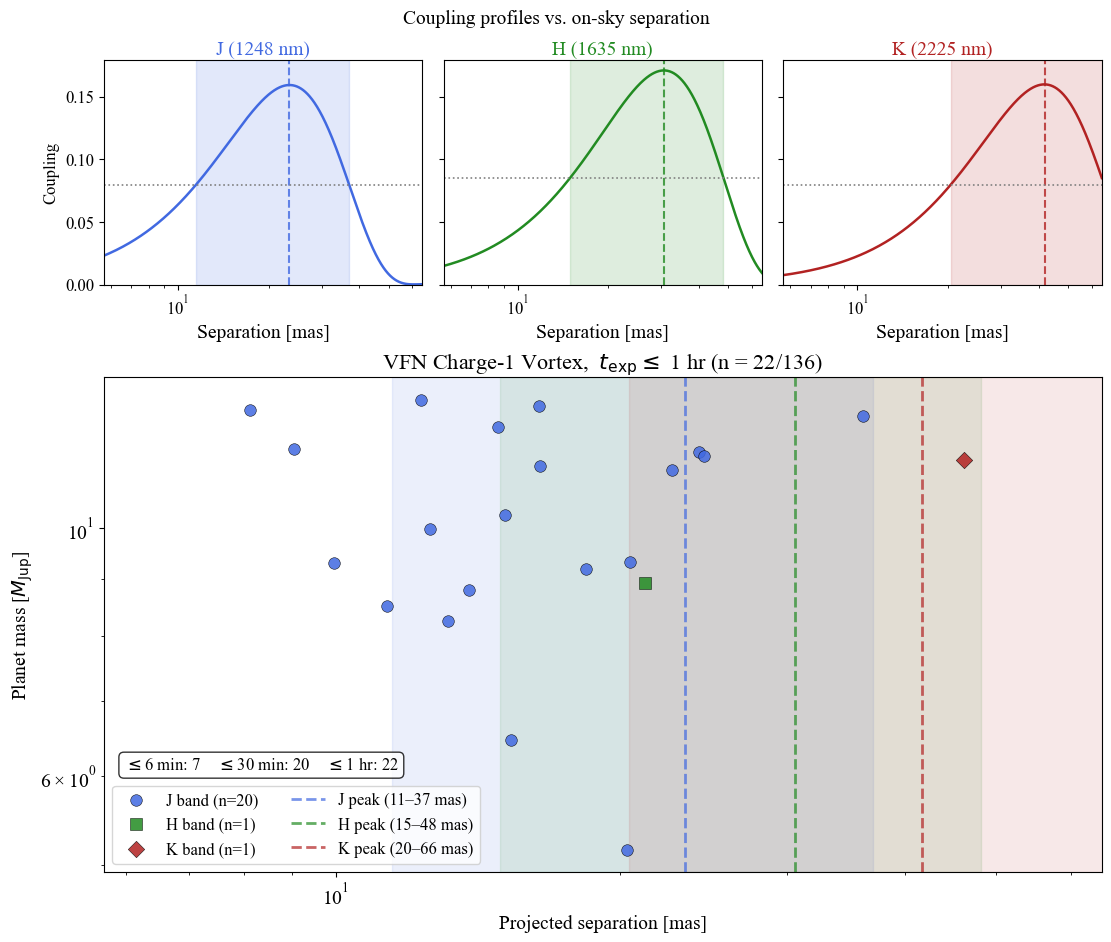

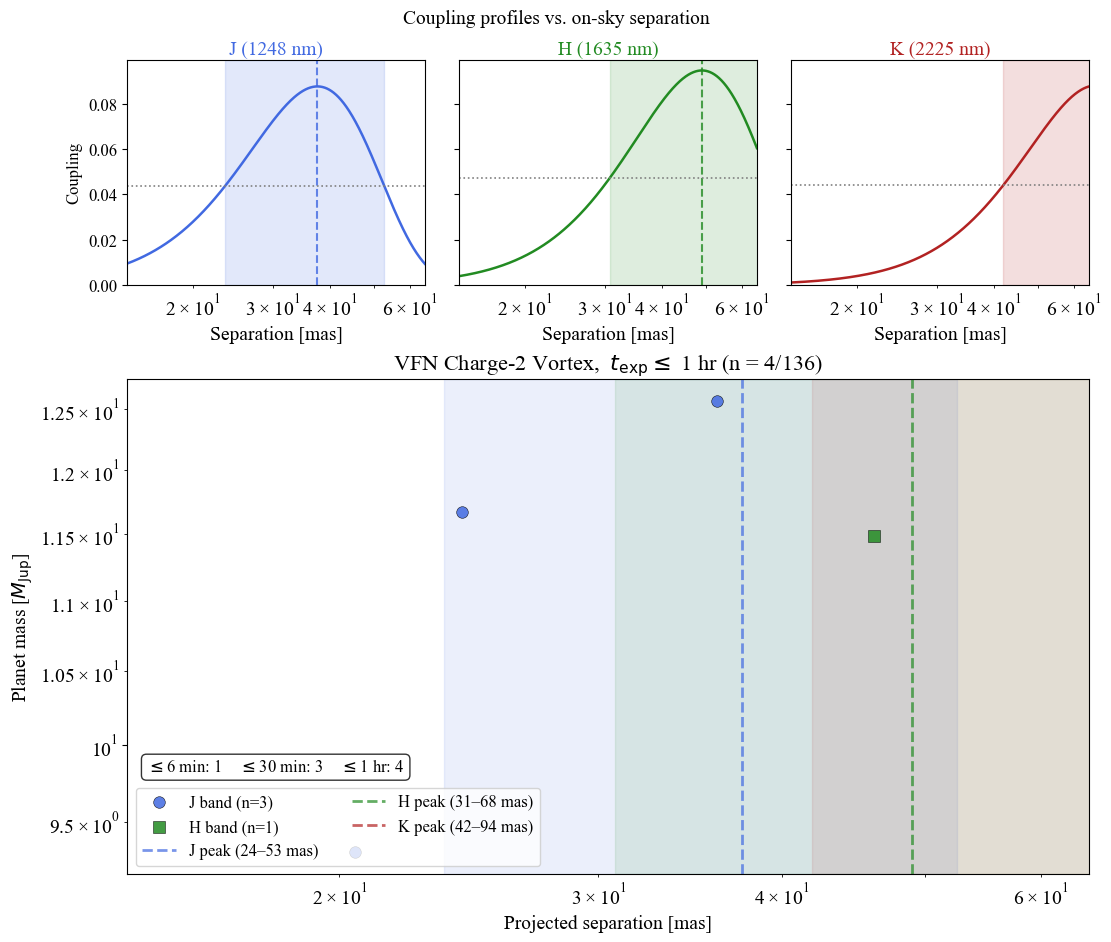

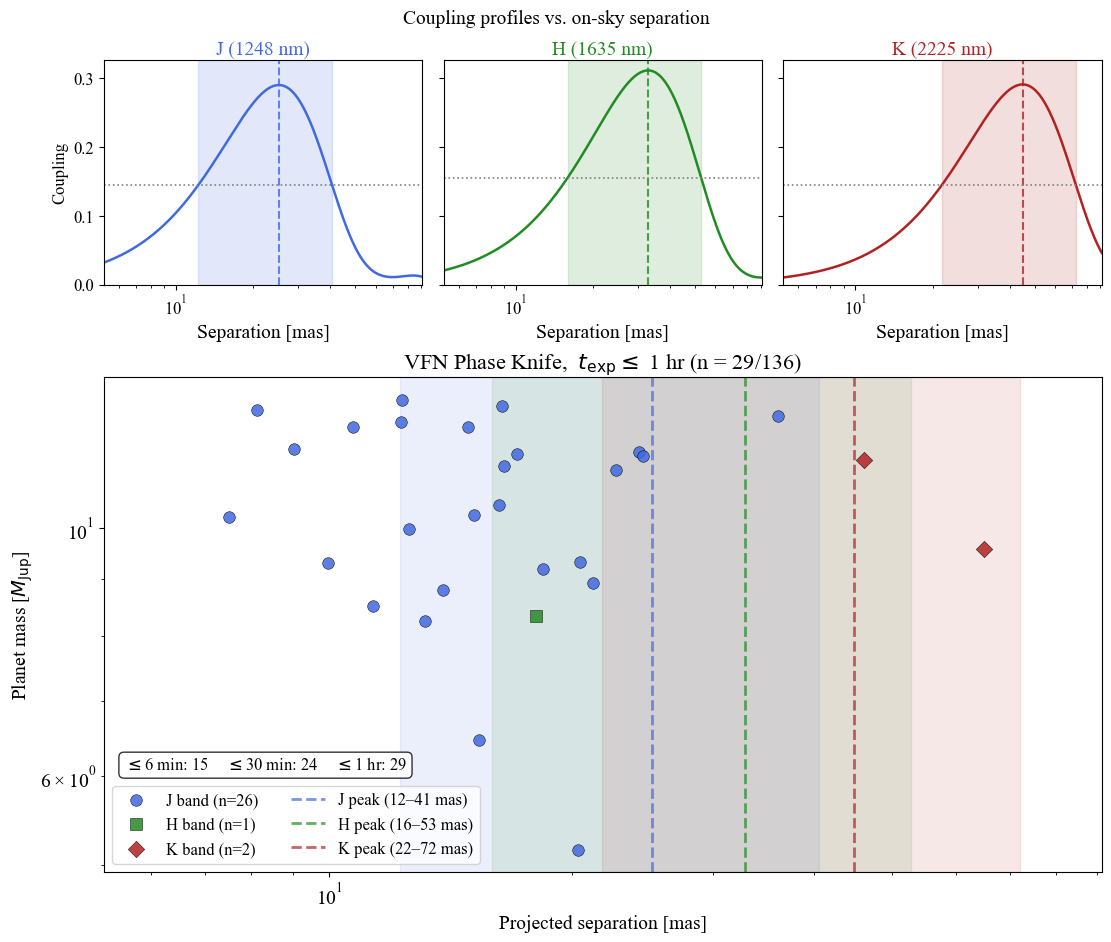

In [69]:
import re
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif', 'Liberation Serif']
plt.rcParams['font.size'] = 14
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['legend.fontsize'] = 11

MAX_HR = 1.0   # only show planets reaching CCF SNR=5 in <= this many hours

det = pd.read_csv(out_detect)

# --- Coupling helpers ---
def load_coupling(filepath):
    """Return (sep_lod, coupling, lam0_m) from a VFN coupling file."""
    with open(filepath) as _f:
        lines = _f.readlines()

    lam_nm = None
    for key in ('Central wavelength', 'Wavelength of this cut'):
        for l in lines:
            if l.lstrip().startswith('#') and key in l:
                m = re.search(r'([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)', l.split(':', 1)[-1])
                if m:
                    lam_nm = float(m.group(1))
                    break
        if lam_nm is not None:
            break

    rows = [l for l in lines if not l.lstrip().startswith('#') and l.strip()]
    if not rows[0][0].isdigit() and rows[0][0] not in '.-':
        rows = rows[1:]
    d = np.loadtxt(rows, delimiter=',')
    return d[:, 0], d[:, 1], (lam_nm * 1e-9 if lam_nm is not None else None)

def half_max_from_profile(sep_lod, coupling, main_lobe_max=3.0):
    """Return (peak_lod, inner_half_lod, outer_half_lod) using the main lobe only."""
    main = sep_lod < main_lobe_max
    i_pk = np.argmax(coupling[main])
    half = coupling[i_pk] / 2.0
    i_in = np.argmin(np.abs(coupling[:i_pk] - half))
    tail = coupling[i_pk:][sep_lod[i_pk:] < main_lobe_max]
    i_out = i_pk + np.argmin(np.abs(tail - half))
    return sep_lod[i_pk], sep_lod[i_in], sep_lod[i_out]

def get_coupling_half_max(filepath):
    sep_lod, coupling, _ = load_coupling(filepath)
    return half_max_from_profile(sep_lod, coupling)

BAND_CENTER_M = {'J': 1.248e-6, 'H': 1.635e-6, 'K': 2.225e-6}   # fallback only
BAND_COLORS   = {'J': 'royalblue', 'H': 'forestgreen', 'K': 'firebrick'}
BAND_MARKERS  = {'J': 'o', 'H': 's', 'K': 'D'}
D_TEL = 10.0

def lod_to_mas(n_lod, lam_m, d_tel=D_TEL):
    """lambda/D -> mas:  sep_rad * 206265 = arcsec, * 1000 = mas."""
    return n_lod * (lam_m / d_tel) * 206265.0 * 1000.0

# --- One figure per mask ---
for mask_name, mask_cfg in MASK_CONFIGS.items():
    best_hr_col = f'etc_{mask_name}_best_hr'
    best_band_col = f'{mask_name}_best_band'

    if best_hr_col not in det.columns:
        continue

    # keep only fast targets
    sub = det[det[best_hr_col] <= MAX_HR].copy()
    if len(sub) == 0:
        print(f'{mask_name}: no planets with t_exp <= {MAX_HR:g} hr; skipping')
        continue

    fig = plt.figure(figsize=(11, 9), constrained_layout=True)
    gs = fig.add_gridspec(2, 3, height_ratios=[1, 2.2])

    ax = fig.add_subplot(gs[1, :])                           # main scatter
    top_axes = {b: fig.add_subplot(gs[0, i], sharex=ax)
                for i, b in enumerate(['J', 'H', 'K'])}

    n_6min  = (sub[best_hr_col] <= 0.1).sum()
    n_30min = (sub[best_hr_col] <= 0.5).sum()

    # Scatter coloured by the band that detects each planet fastest
    for band, marker in BAND_MARKERS.items():
        band_mask = sub[best_band_col] == band
        if band_mask.sum() == 0:
            continue
        ax.scatter(
            sub.loc[band_mask, 'planet_sep_mas'],
            sub.loc[band_mask, 'planet_mass_mj'],
            color=BAND_COLORS[band],
            s=70, alpha=0.85, edgecolors='k', linewidths=0.4,
            marker=marker,
            label=f'{band} band (n={band_mask.sum()})',
            zorder=3
        )

    # Coupling profiles (top) + half-max regions (main)
    for band in ['J', 'H', 'K']:
        filepath = mask_cfg['bands'][band]
        sep_lod, coupling, lam = load_coupling(filepath)
        if lam is None:
            lam = BAND_CENTER_M[band]
            print(f'[{mask_name}/{band}] no wavelength in header; '
                  f'using band center {lam*1e9:.0f} nm')
        peak_lod, inner_lod, outer_lod = half_max_from_profile(sep_lod, coupling)

        sep_mas   = lod_to_mas(sep_lod,   lam)
        inner_mas = lod_to_mas(inner_lod, lam)
        peak_mas  = lod_to_mas(peak_lod,  lam)
        outer_mas = lod_to_mas(outer_lod, lam)

        # main plot shading
        ax.axvspan(inner_mas, outer_mas, alpha=0.10, color=BAND_COLORS[band], zorder=0)
        ax.axvline(peak_mas, color=BAND_COLORS[band], ls='--', lw=2, alpha=0.7,
                   label=f'{band} peak ({inner_mas:.0f}\u2013{outer_mas:.0f} mas)')

        # top profile panel
        axt = top_axes[band]
        good = sep_mas > 0
        axt.plot(sep_mas[good], coupling[good], color=BAND_COLORS[band], lw=1.8)
        axt.axvspan(inner_mas, outer_mas, alpha=0.15, color=BAND_COLORS[band], zorder=0)
        axt.axvline(peak_mas, color=BAND_COLORS[band], ls='--', lw=1.5, alpha=0.8)
        axt.axhline(coupling[sep_lod < 3.0].max() / 2.0,
                    color='gray', ls=':', lw=1.2)
        axt.set_title(f'{band} ({lam*1e9:.0f} nm)', fontsize=14, pad=4,
                      color=BAND_COLORS[band])
        axt.set_xlabel('Separation [mas]', fontsize=14)
        axt.tick_params(labelsize=12)

    top_axes['J'].set_ylabel('Coupling', fontsize=12)
    for band in ['H', 'K']:
        top_axes[band].tick_params(labelleft=False)

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(sub['planet_sep_mas'].min() * 0.7,
                sub['planet_sep_mas'].max() * 1.4)

    ymax = max(a.get_ylim()[1] for a in top_axes.values())
    for a in top_axes.values():
        a.set_ylim(0, ymax)

    ax.set_xlabel('Projected separation [mas]')
    ax.set_ylabel('Planet mass [$M_\\mathrm{Jup}$]')
    ax.set_title(f'VFN {mask_cfg["label"]}, '
                 f' $t_\\mathrm{{exp}} \\leq$ {MAX_HR:g} hr (n = {len(sub)}/{len(det)})')
    ax.legend(loc='lower left', fontsize=12, ncol=2)

    ax.text(0.02, 0.2,
            f'$\\leq$6 min: {n_6min}    $\\leq$30 min: {n_30min}    '
            f'$\\leq${MAX_HR:g} hr: {len(sub)}',
            transform=ax.transAxes, fontsize=12, va='bottom',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

    fig.suptitle('Coupling profiles vs. on-sky separation', fontsize=14, y=1.03)
    plt.savefig(f'/Users/tatumumiamaka/Desktop/HISPEC/vfn_{mask_name}_detectability_'
                f'under{MAX_HR:g}hr.png', dpi=300, bbox_inches='tight')
    plt.show()


=== MASK LEADERBOARD (ranked by detections per 10-hr night) ===
      mask           label  N<=1hr  N<=5hr  N<=10hr  median_hr  fastest_hr  per_10hr_night  min_mass_mj  N_J  N_H  N_K
phaseknife     Phase Knife      29      46       50   0.093350    0.000608              32      5.16217   26    1    2
   charge1 Charge-1 Vortex      22      34       41   0.165973    0.002075              25      5.16217   20    1    1
   charge2 Charge-2 Vortex       4       9       16   0.275844    0.010984               7      9.31267    3    1    0


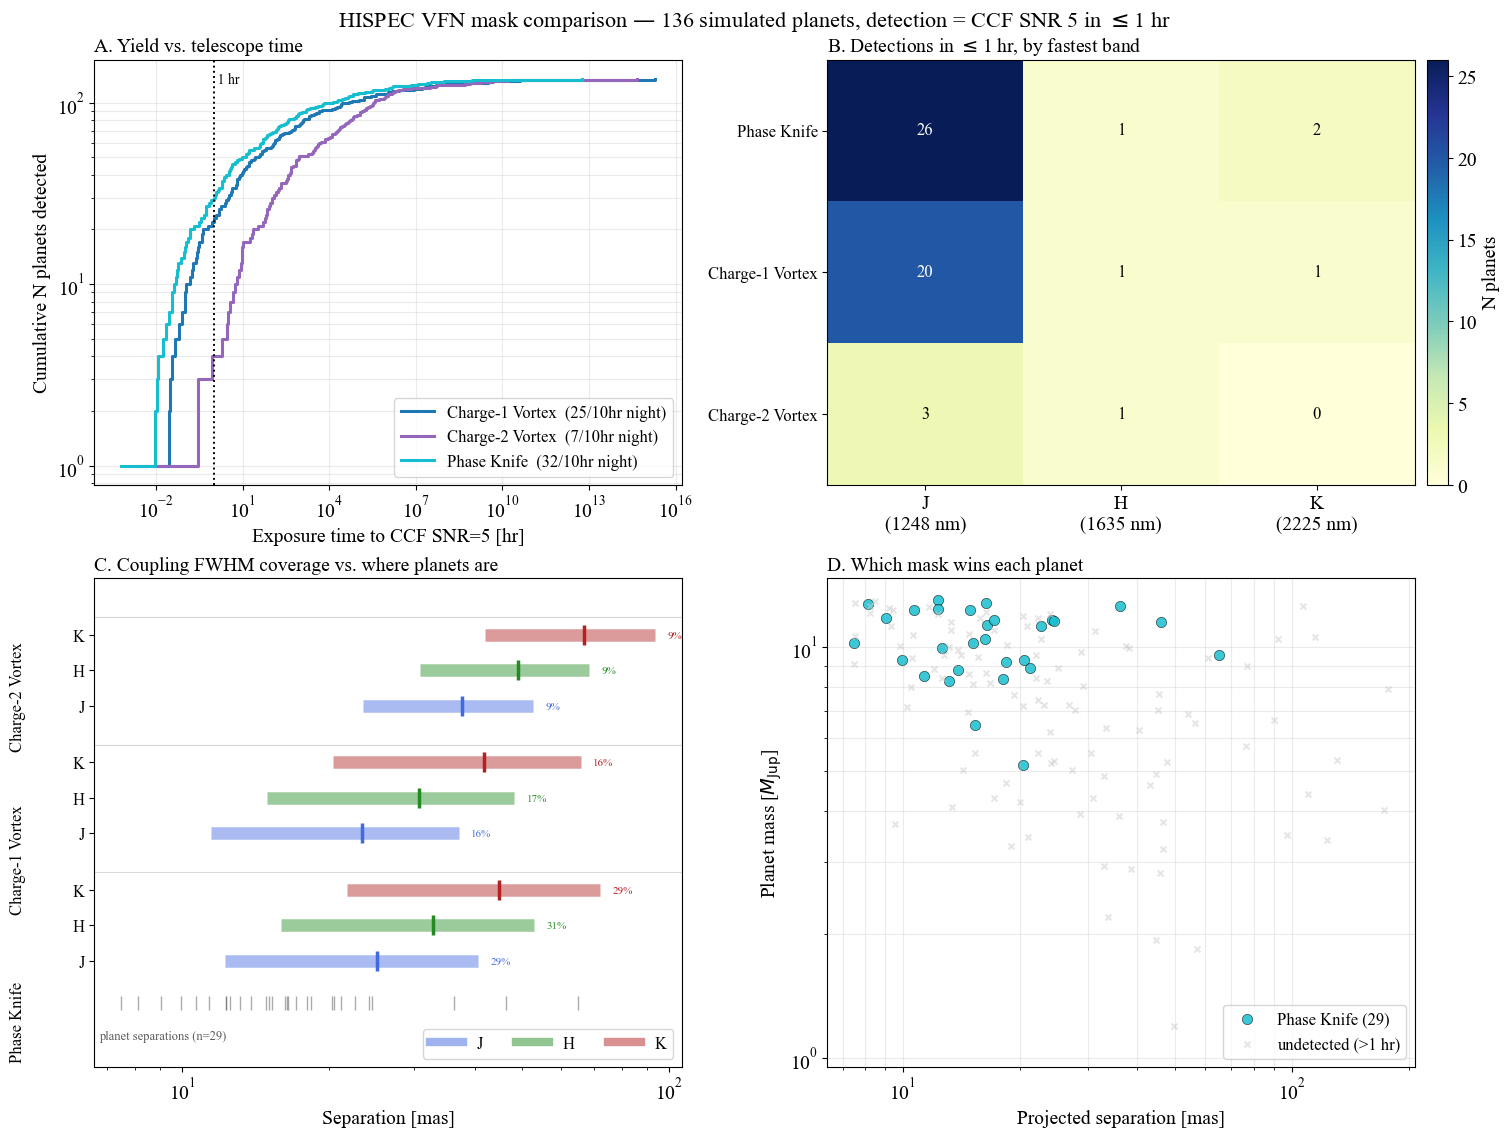

In [77]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif', 'Liberation Serif']
plt.rcParams['font.size'] = 13

MAX_HR    = 1.0     # "detected" threshold for the headline counts
NIGHT_HR  = 10.0    # observing budget for the per-night metric
BANDS     = ['J', 'H', 'K']
BAND_CENTER_M = {'J': 1.248e-6, 'H': 1.635e-6, 'K': 2.225e-6}
BAND_COLORS   = {'J': 'royalblue', 'H': 'forestgreen', 'K': 'firebrick'}
D_TEL = 10.0

det = pd.read_csv(out_detect)

# ---------- reuse the loaders ----------
def load_coupling(filepath):
    with open(filepath) as _f:
        lines = _f.readlines()
    lam_nm = None
    for key in ('Central wavelength', 'Wavelength of this cut'):
        for l in lines:
            if l.lstrip().startswith('#') and key in l:
                m = re.search(r'([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)', l.split(':', 1)[-1])
                if m:
                    lam_nm = float(m.group(1)); break
        if lam_nm is not None:
            break
    rows = [l for l in lines if not l.lstrip().startswith('#') and l.strip()]
    if not rows[0][0].isdigit() and rows[0][0] not in '.-':
        rows = rows[1:]
    d = np.loadtxt(rows, delimiter=',')
    return d[:, 0], d[:, 1], (lam_nm * 1e-9 if lam_nm is not None else None)

def half_max_from_profile(sep_lod, coupling, main_lobe_max=3.0):
    i_end = np.searchsorted(sep_lod, main_lobe_max)
    i_pk  = int(np.argmax(coupling[:i_end]))
    target = coupling[i_pk] / 2.0
    inner = np.interp(target, coupling[:i_pk + 1], sep_lod[:i_pk + 1])
    outer = np.interp(target, coupling[i_pk:i_end][::-1], sep_lod[i_pk:i_end][::-1])
    return sep_lod[i_pk], inner, outer

def lod_to_mas(n_lod, lam_m, d_tel=D_TEL):
    return n_lod * (lam_m / d_tel) * 206265.0 * 1000.0

def per_night(hrs, budget=NIGHT_HR):
    """Greedy count: how many targets fit in `budget` hours, cheapest first."""
    s = np.sort(np.asarray(hrs)[np.isfinite(hrs)])
    return int(np.searchsorted(np.cumsum(s), budget)) if len(s) else 0

# ---------- build the per-mask summary ----------
masks = [m for m in MASK_CONFIGS if f'etc_{m}_best_hr' in det.columns]
if not masks:
    raise KeyError('no etc_<mask>_best_hr columns found')

MASK_COLORS = dict(zip(masks, plt.cm.tab10(np.linspace(0, 0.9, len(masks)))))

rows, coverage = [], {}
for m in masks:
    hr   = det[f'etc_{m}_best_hr']
    band = det[f'{m}_best_band']
    fast = hr <= MAX_HR
    rows.append({
        'mask': m,
        'label': MASK_CONFIGS[m].get('label', m),
        f'N<={MAX_HR:g}hr': int(fast.sum()),
        'N<=5hr':  int((hr <= 5).sum()),
        'N<=10hr': int((hr <= 10).sum()),
        'median_hr': float(np.nanmedian(hr[fast])) if fast.any() else np.nan,
        'fastest_hr': float(np.nanmin(hr)) if np.isfinite(hr).any() else np.nan,
        f'per_{NIGHT_HR:g}hr_night': per_night(hr),
        'min_mass_mj': float(det.loc[fast, 'planet_mass_mj'].min()) if fast.any() else np.nan,
        **{f'N_{b}': int(((band == b) & fast).sum()) for b in BANDS},
    })

    cov = {}
    for b in BANDS:
        sep_lod, cpl, lam = load_coupling(MASK_CONFIGS[m]['bands'][b])
        lam = lam or BAND_CENTER_M[b]
        pk, lo, hi = half_max_from_profile(sep_lod, cpl)
        cov[b] = dict(peak=lod_to_mas(pk, lam), lo=lod_to_mas(lo, lam),
                      hi=lod_to_mas(hi, lam), eta_pk=cpl[sep_lod < 3.0].max())
    coverage[m] = cov

summary = pd.DataFrame(rows).sort_values(f'per_{NIGHT_HR:g}hr_night', ascending=False)
print('\n=== MASK LEADERBOARD (ranked by detections per '
      f'{NIGHT_HR:g}-hr night) ===')
print(summary.to_string(index=False))

# per-planet winner: which mask is fastest
hr_mat = det[[f'etc_{m}_best_hr' for m in masks]].to_numpy(dtype=float)
hr_mat = np.where(np.isfinite(hr_mat), hr_mat, np.inf)
winner_idx = np.argmin(hr_mat, axis=1)
winner_hr  = hr_mat[np.arange(len(det)), winner_idx]
det['_winner'] = [masks[i] for i in winner_idx]
det['_winner_hr'] = winner_hr

# ================= FIGURE =================
fig = plt.figure(figsize=(15, 11), constrained_layout=True)
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.15])

# ---- A: cumulative yield vs exposure time ----
axA = fig.add_subplot(gs[0, 0])
for m in masks:
    hr = np.sort(det[f'etc_{m}_best_hr'].dropna().to_numpy())
    hr = hr[hr > 0]
    axA.step(hr, np.arange(1, len(hr) + 1), where='post', lw=2.2,
             color=MASK_COLORS[m],
             label=f"{MASK_CONFIGS[m].get('label', m)}  "
                   f"({per_night(hr)}/{NIGHT_HR:g}hr night)")
axA.axvline(MAX_HR, color='k', ls=':', lw=1.4)
axA.text(MAX_HR, 0.97, f' {MAX_HR:g} hr', transform=axA.get_xaxis_transform(),
         va='top', fontsize=10)
axA.set_xscale('log'); axA.set_yscale('log')
axA.set_xlabel('Exposure time to CCF SNR=5 [hr]')
axA.set_ylabel('Cumulative N planets detected')
axA.set_title('A. Yield vs. telescope time', fontsize=14, loc='left')
axA.legend(fontsize=12, loc='lower right')
axA.grid(alpha=0.25, which='both')

# ---- B: yield heatmap, mask x band ----
axB = fig.add_subplot(gs[0, 1])
order = summary['mask'].tolist()
M = np.array([[summary.set_index('mask').loc[m, f'N_{b}'] for b in BANDS]
              for m in order], dtype=float)
im = axB.imshow(M, cmap='YlGnBu', aspect='auto')
axB.set_xticks(range(len(BANDS)))
axB.set_xticklabels([f'{b}\n({BAND_CENTER_M[b]*1e9:.0f} nm)' for b in BANDS])
axB.set_yticks(range(len(order)))
axB.set_yticklabels([MASK_CONFIGS[m].get('label', m) for m in order], fontsize=12)
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        axB.text(j, i, f'{int(M[i, j])}', ha='center', va='center', fontsize=12,
                 color='white' if M[i, j] > M.max() * 0.55 else 'black')
axB.set_title(f'B. Detections in $\\leq${MAX_HR:g} hr, by fastest band',
              fontsize=14, loc='left')
fig.colorbar(im, ax=axB, pad=0.02, label='N planets')

# ---- C: coverage ribbons vs planet separations ----
axC = fig.add_subplot(gs[1, 0])
yticks, ylabels = [], []
y = 0
for m in order:
    for b in BANDS:
        c = coverage[m][b]
        axC.plot([c['lo'], c['hi']], [y, y], lw=9, solid_capstyle='butt',
                 color=BAND_COLORS[b], alpha=0.45)
        axC.plot(c['peak'], y, marker='|', ms=14, mew=2.5, color=BAND_COLORS[b])
        axC.text(c['hi'] * 1.06, y, f"{c['eta_pk']*100:.0f}%", va='center',
                 fontsize=8, color=BAND_COLORS[b])
        yticks.append(y); ylabels.append(b)
        y += 1
    axC.axhline(y - 0.5, color='0.85', lw=0.8)
    axC.text(axC.get_xlim()[0], y - 2, '', fontsize=1)  # spacer
    y += 0.6

# rug of real planet separations (all masks pooled, detectable somewhere)
seps = det.loc[det['_winner_hr'] <= MAX_HR, 'planet_sep_mas'].dropna()
axC.plot(seps, np.full(len(seps), -1.2), '|', color='0.35', ms=10, alpha=0.5)
axC.text(seps.min() * 0.9, -2.2, f'planet separations (n={len(seps)})',
         fontsize=9, color='0.35')

axC.set_xscale('log')
axC.set_yticks(yticks); axC.set_yticklabels(ylabels, fontsize=12)
axC.set_ylim(-3, y)
axC.set_xlabel('Separation [mas]')
axC.set_title('C. Coupling FWHM coverage vs. where planets are',
              fontsize=14, loc='left')
for i, m in enumerate(order):
    axC.text(-0.13, (i * 3.6 + 1) / y, MASK_CONFIGS[m].get('label', m),
             transform=axC.transAxes, rotation=90, va='center', ha='center',
             fontsize=12)
axC.legend(handles=[Line2D([], [], color=BAND_COLORS[b], lw=6, alpha=0.5, label=b)
                    for b in BANDS], fontsize=12, loc='lower right', ncol=3)

# ---- D: winner map ----
axD = fig.add_subplot(gs[1, 1])
win = det[det['_winner_hr'] <= MAX_HR]
for m in masks:
    s = win[win['_winner'] == m]
    if len(s) == 0:
        continue
    axD.scatter(s['planet_sep_mas'], s['planet_mass_mj'],
                color=MASK_COLORS[m], s=55, alpha=0.85,
                edgecolors='k', linewidths=0.4,
                label=f"{MASK_CONFIGS[m].get('label', m)} ({len(s)})")
lost = det[(det['_winner_hr'] > MAX_HR) & np.isfinite(det['_winner_hr'])]
axD.scatter(lost['planet_sep_mas'], lost['planet_mass_mj'],
            color='0.8', s=18, alpha=0.5, marker='x', zorder=1,
            label=f'undetected (>{MAX_HR:g} hr)')
axD.set_xscale('log'); axD.set_yscale('log')
axD.set_xlabel('Projected separation [mas]')
axD.set_ylabel('Planet mass [$M_\\mathrm{Jup}$]')
axD.set_title('D. Which mask wins each planet', fontsize=14, loc='left')
axD.legend(fontsize=12, loc='lower right')
axD.grid(alpha=0.25, which='both')

fig.suptitle(f'HISPEC VFN mask comparison \u2014 {len(det)} simulated planets, '
             f'detection = CCF SNR 5 in $\\leq${MAX_HR:g} hr',
             fontsize=16, y=1.02)
plt.savefig('/Users/tatumumiamaka/Desktop/HISPEC/vfn_mask_comparison.png',
            dpi=300, bbox_inches='tight')
plt.show()